In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from  sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score





In [3]:
df=pd.read_csv('HDC.csv.csv')

In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.shape

(920, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [10]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [11]:
df['num'].value_counts(normalize = True)

,proportion
num,
0,0.446739
1,0.288043
2,0.118478
3,0.116304
4,0.030435


<Axes: xlabel='age', ylabel='chol'>

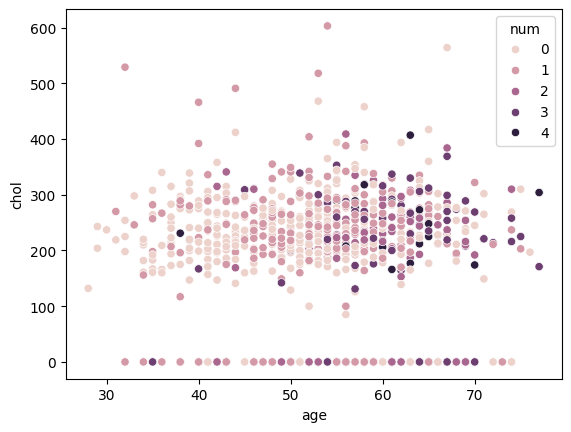

In [12]:
sns.scatterplot( x = 'age',y = 'chol', data = df,hue='num')


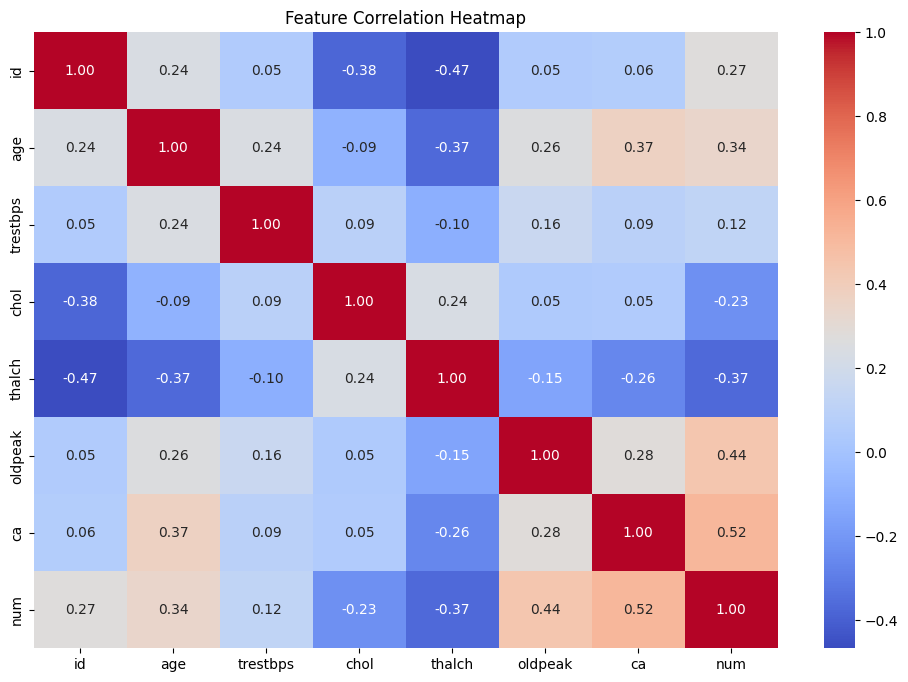

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [14]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [15]:
print(df['num'].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [16]:
df = df.drop(columns=["id",'dataset','thal' , 'ca','slope'])

In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalch    865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  num       920 non-null    int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 79.2+ KB


In [18]:
df.shape

(920, 11)

In [19]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


In [20]:
df.select_dtypes(include=['object'])

,sex,cp,fbs,restecg,exang
0,Male,typical angina,True,lv hypertrophy,False
1,Male,asymptomatic,False,lv hypertrophy,True
2,Male,asymptomatic,False,lv hypertrophy,True
3,Male,non-anginal,False,normal,False
4,Female,atypical angina,False,lv hypertrophy,False
...,...,...,...,...,...
915,Female,asymptomatic,True,st-t abnormality,False
916,Male,typical angina,False,st-t abnormality,NaN
917,Male,asymptomatic,True,st-t abnormality,False
918,Male,asymptomatic,True,lv hypertrophy,NaN


In [21]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    if df[col].isnull().sum() < 100:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.infer_objects(copy=False)

/tmp/ipykernel_1372/2434624377.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [22]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,0
restecg,0
thalch,55
exang,0
oldpeak,62


In [23]:
df.select_dtypes(include=['int64','float64'])

,age,trestbps,chol,thalch,oldpeak,num
0,63,145.0,233.0,150.0,2.3,0
1,67,160.0,286.0,108.0,1.5,2
2,67,120.0,229.0,129.0,2.6,1
3,37,130.0,250.0,187.0,3.5,0
4,41,130.0,204.0,172.0,1.4,0
...,...,...,...,...,...,...
915,54,127.0,333.0,154.0,0.0,1
916,62,NaN,139.0,NaN,NaN,0
917,55,122.0,223.0,100.0,0.0,2
918,58,NaN,385.0,NaN,NaN,0


In [24]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    if df[col].isnull().sum() < 100:
        df[col] = df[col].fillna(df[col].median())

In [25]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [26]:
df = pd.get_dummies(df, columns=['cp'], drop_first=True, dtype=int)

In [27]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=int)

In [28]:
df = pd.get_dummies(df, columns=['restecg'], drop_first=True, dtype=int)

In [29]:
x = df.drop(columns = 'num', axis = 1)

y = df['num']

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
x_train.shape

(736, 13)

In [32]:
x_test.shape

(184, 13)

In [34]:
print(df['fbs'].value_counts())

fbs
False    782
True     138
Name: count, dtype: int64


In [35]:
print(df['exang'].value_counts())

exang
False    583
True     337
Name: count, dtype: int64


In [37]:
num_cols = ['age', 'trestbps', 'chol',  'oldpeak']

scaler = StandardScaler()

In [38]:
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [ ]:
#y_train = (y_train > 0).astype(int)
#y_test = (y_test > 0).astype(int)

#print(y_train.value_counts())

num
1    400
0    336
Name: count, dtype: int64


In [39]:
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

num
0    336
1    211
2     84
3     81
4     24
Name: count, dtype: int64
num
0    75
1    54
2    25
3    26
4     4
Name: count, dtype: int64


for logistics regression


In [41]:
lr_multiclass = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

lr_multiclass.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [42]:
y_test_pred = lr_multiclass.predict(x_test)
y_test_prob = lr_multiclass.predict_proba(x_test)

In [43]:
preview_df = pd.DataFrame({
    'Patient Index': x_test.index[:10],
    'Actual Stage': y_test.iloc[:10].values,
    'Predicted Stage': y_test_pred[:10],
    'Confidence (%)': np.round(np.max(y_test_prob[:10], axis=1) * 100, 1),
    'Correct?': y_test.iloc[:10].values == y_test_pred[:10]
})

print("=== PREDICTIONS VS ACTUAL (FIRST 10 PATIENTS) ===")
print(preview_df.to_string(index=False))

=== PREDICTIONS VS ACTUAL (FIRST 10 PATIENTS) ===
 Patient Index  Actual Stage  Predicted Stage  Confidence (%)  Correct?
           319             0                0            89.4      True
           377             0                0            77.9      True
           538             1                1            69.3      True
           296             3                3            31.6      True
           531             1                0            72.2     False
            70             0                0            90.5      True
           493             1                0            80.3     False
           664             2                1            39.7     False
           796             2                1            35.3     False
            30             0                0            83.6      True


In [46]:
acc = accuracy_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred, average='weighted')
prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')

In [47]:
print(acc)
print(rec)
print(prec)
print(f1)
print(roc_auc)

0.5380434782608695
0.5380434782608695
0.4678959627329192
0.4865557148165844
0.7928404896719963


In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== PER-STAGE CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred, zero_division=0))

# 5x5 Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

=== PER-STAGE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.67      0.89      0.77        75
           1       0.43      0.50      0.46        54
           2       0.30      0.12      0.17        25
           3       0.20      0.08      0.11        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.32      0.32      0.30       184
weighted avg       0.47      0.54      0.49       184

Confusion Matrix:
 [[67  8  0  0  0]
 [22 27  1  3  1]
 [ 4 15  3  3  0]
 [ 7 12  5  2  0]
 [ 0  1  1  2  0]]


RANDOM FOREST

In [49]:
rf_multiclass = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42)

In [52]:
rf_multiclass.fit(x_train, y_train)
rf_pred_multi = rf_multiclass.predict(x_test)

In [53]:
rf_prob_multi = rf_multiclass.predict_proba(x_test)

In [54]:
rf_acc = accuracy_score(y_test, rf_pred_multi)
rf_rec = recall_score(y_test, rf_pred_multi, average='weighted')
rf_prec = precision_score(y_test, rf_pred_multi, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred_multi, average='weighted')
rf_auc = roc_auc_score(y_test, rf_prob_multi, multi_class='ovr', average='weighted')

In [55]:
print(rf_acc)
print(rf_acc)
print(rf_prec)
print(rf_f1 )
print(rf_auc )

0.5489130434782609
0.5489130434782609
0.4951826234926221
0.5095800694768637
0.8069824326426778


XGBoost

In [58]:
sample_weights_gb = compute_sample_weight(class_weight='balanced', y=y_train)

gb_multiclass = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

In [59]:
gb_multiclass.fit(x_train, y_train, sample_weight=sample_weights_gb)



GradientBoostingClassifier(learning_rate=0.08, n_estimators=150,
                           random_state=42, subsample=0.8)

In [60]:

gb_pred_multi = gb_multiclass.predict(x_test)
gb_prob_multi = gb_multiclass.predict_proba(x_test)

In [61]:
gb_acc = accuracy_score(y_test, gb_pred_multi)
gb_rec = recall_score(y_test, gb_pred_multi, average='weighted')
gb_prec = precision_score(y_test, gb_pred_multi, average='weighted', zero_division=0)
gb_f1 = f1_score(y_test, gb_pred_multi, average='weighted')
gb_auc = roc_auc_score(y_test, gb_prob_multi, multi_class='ovr', average='weighted')

In [63]:
print(gb_acc)
print(gb_rec)
print(gb_prec)
print(gb_f1)
print(gb_auc)

0.5380434782608695
0.5380434782608695
0.5358271662041318
0.5358283787435816
0.8117417092598104


SVM

In [64]:
# 1. Pipeline: Standardize features + fit Balanced RBF SVM
svm_multiclass = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1.0,
        class_weight='balanced',
        probability=True,
        random_state=42
    )
)

svm_multiclass.fit(x_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [65]:
svm_pred_multi = svm_multiclass.predict(x_test)
svm_prob_multi = svm_multiclass.predict_proba(x_test)

In [66]:
svm_acc = accuracy_score(y_test, svm_pred_multi)
svm_rec = recall_score(y_test, svm_pred_multi, average='weighted')
svm_prec = precision_score(y_test, svm_pred_multi, average='weighted', zero_division=0)
svm_f1 = f1_score(y_test, svm_pred_multi, average='weighted')
svm_auc = roc_auc_score(y_test, svm_prob_multi, multi_class='ovr', average='weighted')

In [68]:
print(svm_acc)
print(svm_rec)
print(svm_prec)
print(svm_f1)
print(svm_auc)

0.5
0.5
0.5141084219794864
0.5003346379506614
0.7956406384120303


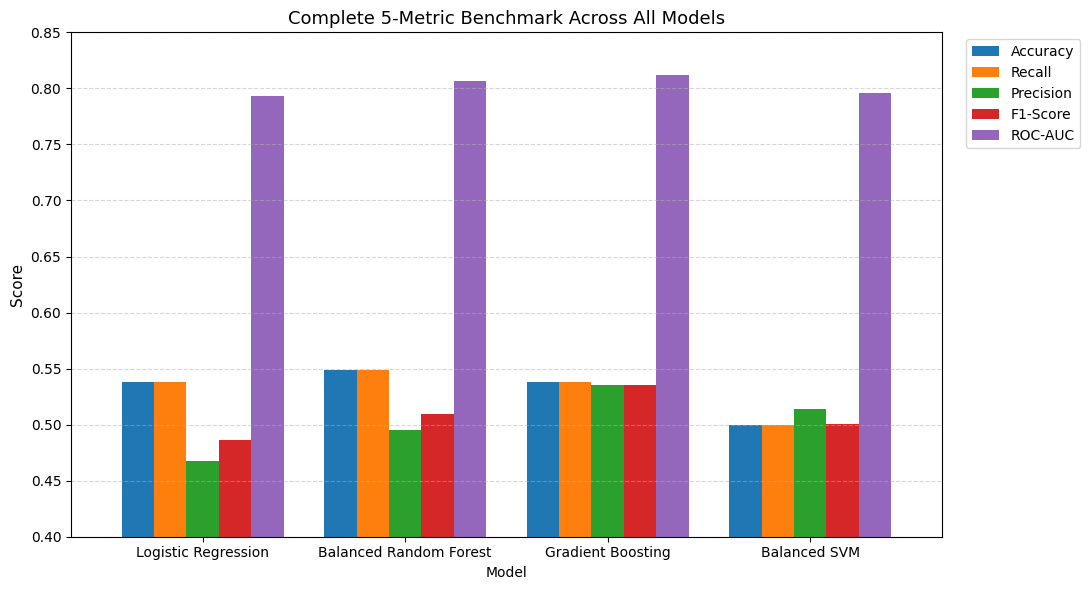

In [71]:
df_all = pd.DataFrame({
    'Model': ['Logistic Regression', 'Balanced Random Forest', 'Gradient Boosting', 'Balanced SVM'],
    'Accuracy': [0.5380, 0.5489, 0.5380, 0.5000],
    'Recall': [0.5380, 0.5489, 0.5380, 0.5000],
    'Precision': [0.4679, 0.4952, 0.5358, 0.5141],
    'F1-Score': [0.4866, 0.5096, 0.5358, 0.5003],
    'ROC-AUC': [0.7928, 0.8070, 0.8117, 0.7956]
}).set_index('Model')

ax = df_all.plot(kind='bar', figsize=(11, 6), width=0.8)
plt.title('Complete 5-Metric Benchmark Across All Models', fontsize=13)
plt.ylabel('Score', fontsize=11)
plt.ylim(0.4, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0, fontsize=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [75]:
# Map 5 classes into 3 clinical risk tiers: 0 -> 0 (Low), [1,2] -> 1 (Moderate), [3,4] -> 2 (Severe)
risk_map = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}
y_train_3class = y_train.map(risk_map)
y_test_3class = y_test.map(risk_map)

# Compute balanced sample weights
sw_3 = compute_sample_weight(class_weight='balanced', y=y_train_3class)

# Fit Champion Model: Gradient Boosting
gb_3tier = GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=3, random_state=42)
gb_3tier.fit(x_train, y_train_3class, sample_weight=sw_3)

# Predictions & Probabilities
y_pred_3 = gb_3tier.predict(x_test)
y_prob_3 = gb_3tier.predict_proba(x_test)

print("=== 3-TIER CLINICAL RISK REPORT (GRADIENT BOOSTING) ===")
print(classification_report(y_test_3class, y_pred_3, target_names=['No Disease', 'Moderate Risk', 'Severe Risk']))
print(f"Multiclass ROC-AUC (OvR): {roc_auc_score(y_test_3class, y_prob_3, multi_class='ovr', average='weighted'):.4f}")

=== 3-TIER CLINICAL RISK REPORT (GRADIENT BOOSTING) ===
               precision    recall  f1-score   support

   No Disease       0.76      0.84      0.80        75
Moderate Risk       0.63      0.48      0.55        79
  Severe Risk       0.29      0.40      0.34        30

     accuracy                           0.61       184
    macro avg       0.56      0.57      0.56       184
 weighted avg       0.63      0.61      0.61       184

Multiclass ROC-AUC (OvR): 0.8131


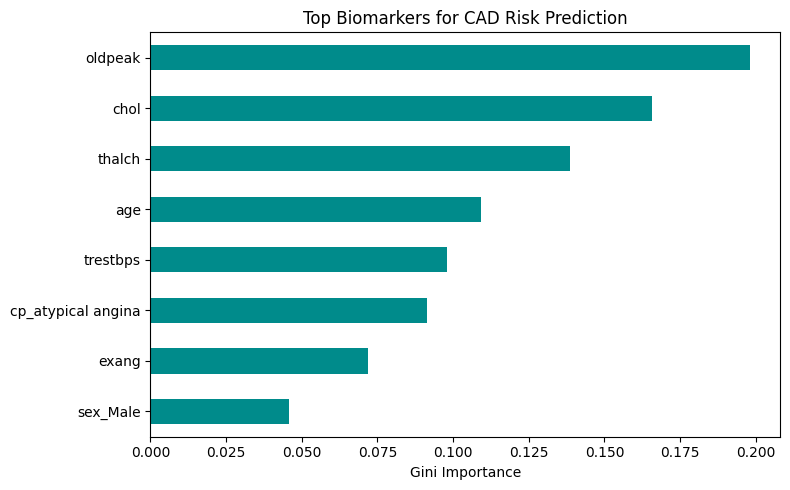

In [74]:
feat_imp = pd.Series(gb_3tier.feature_importances_, index=x_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.tail(8).plot(kind='barh', color='darkcyan')
plt.title("Top Biomarkers for CAD Risk Prediction")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()